Homework 1 – EDA by Pritesh Das (ID: 1002333230)


Subject: Data Visualization DASC 5305


region_2.csv is the original dataset shared to me by the professor.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set(style="whitegrid")
plt.rcParams["figure.dpi"] = 120


Loading the dataset which contains statistics and details on terrorism in the Central America and Carribean Regions

In [26]:
file_path = "/content/region_2.csv"


df = pd.read_csv(file_path, low_memory=False)

print("Shape of raw data:", df.shape)

print("\nPreview of data:")
print(df.head())

print("\nColumn info:")
print(df.info())


Shape of raw data: (10386, 135)

Preview of data:
        eventid  iyear  imonth  iday approxdate  extended resolution  country  \
0  1.970000e+11   1970       7     2        NaN         0        NaN       58   
1  1.970010e+11   1970       1    20        NaN         0        NaN       83   
2  1.970030e+11   1970       3     6        NaN         1   3/8/1970       83   
3  1.970030e+11   1970       3    24        NaN         1  3/26/1970       58   
4  1.970030e+11   1970       3    31        NaN         1   4/5/1970       83   

          country_txt  region  ... addnotes scite1 scite2  scite3  dbsource  \
0  Dominican Republic       2  ...      NaN    NaN    NaN     NaN      PGIS   
1           Guatemala       2  ...      NaN    NaN    NaN     NaN      PGIS   
2           Guatemala       2  ...      NaN    NaN    NaN     NaN      PGIS   
3  Dominican Republic       2  ...      NaN    NaN    NaN     NaN      PGIS   
4           Guatemala       2  ...      NaN    NaN    NaN     NaN   

Data Cleaning

In [27]:
print("\nNumber of duplicate rows before dropping:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Number of duplicate rows after dropping:", df.duplicated().sum())
print("Shape after dropping duplicates:", df.shape)



cols_with_unknown = [
    "nkill", "nkillus", "nkillter",
    "nwound", "nwoundus", "nwoundte",
    "INT_LOG", "INT_IDEO", "INT_MISC", "INT_ANY"
]

for col in cols_with_unknown:
    if col in df.columns:

        df[col] = df[col].replace(-9, np.nan)


print("\nMissing values (top 20 columns):")
print(df.isna().sum().sort_values(ascending=False).head(20))



Number of duplicate rows before dropping: 1233
Number of duplicate rows after dropping: 0
Shape after dropping duplicates: (9153, 135)

Missing values (top 20 columns):
claim3              9153
gname3              9153
gsubname2           9153
gsubname3           9153
guncertain3         9153
attacktype3_txt     9153
attacktype3         9153
claimmode2          9153
ransomnote          9153
claimmode3_txt      9153
claimmode3          9153
claimmode2_txt      9153
claim2              9153
ransomamtus         9152
ransompaidus        9151
targsubtype3        9147
targsubtype3_txt    9147
corp3               9147
attacktype2         9147
attacktype2_txt     9147
dtype: int64


Selection of Features for EDA and Descriptive Statistics

6 variables shall be meaningfully explored:

iyear: year of incident

country_txt: country name

attacktype1_txt: primary attack type

targtype1_txt: primary target type

nkill: number of fatalities

nwound: number of wounded

In [28]:
feature_candidates = [
    "iyear",
    "country_txt",
    "attacktype1_txt",
    "targtype1_txt",
    "nkill",
    "nwound"
]

features = [f for f in feature_candidates if f in df.columns]
print("\nSelected features for EDA:", features)


numeric_cols = [c for c in ["nkill", "nwound"] if c in df.columns]
if numeric_cols:
    print("\nDescriptive statistics for casualty variables:")
    print(df[numeric_cols].describe())


categorical_cols = [
    c for c in ["country_txt", "attacktype1_txt", "targtype1_txt"]
    if c in df.columns
]

for col in categorical_cols:
    print(f"\nTop 10 categories for {col}:")
    print(df[col].value_counts().head(10))

if "iyear" in df.columns:
    print("\nYear range (min, max):", df["iyear"].min(), df["iyear"].max())



Selected features for EDA: ['iyear', 'country_txt', 'attacktype1_txt', 'targtype1_txt', 'nkill', 'nwound']

Descriptive statistics for casualty variables:
             nkill       nwound
count  7095.000000  6945.000000
mean      4.028612     1.289705
std      12.290977     4.680444
min       0.000000     0.000000
25%       0.000000     0.000000
50%       1.000000     0.000000
75%       3.000000     0.000000
max     300.000000   130.000000

Top 10 categories for country_txt:
country_txt
El Salvador           4350
Guatemala             1918
Nicaragua             1911
Honduras               316
Haiti                  224
Panama                 118
Dominican Republic      69
Costa Rica              69
Guadeloupe              50
Jamaica                 34
Name: count, dtype: int64

Top 10 categories for attacktype1_txt:
attacktype1_txt
Armed Assault                          4231
Bombing/Explosion                      2312
Assassination                          1234
Hostage Taking (Kidnappi

Visualizations

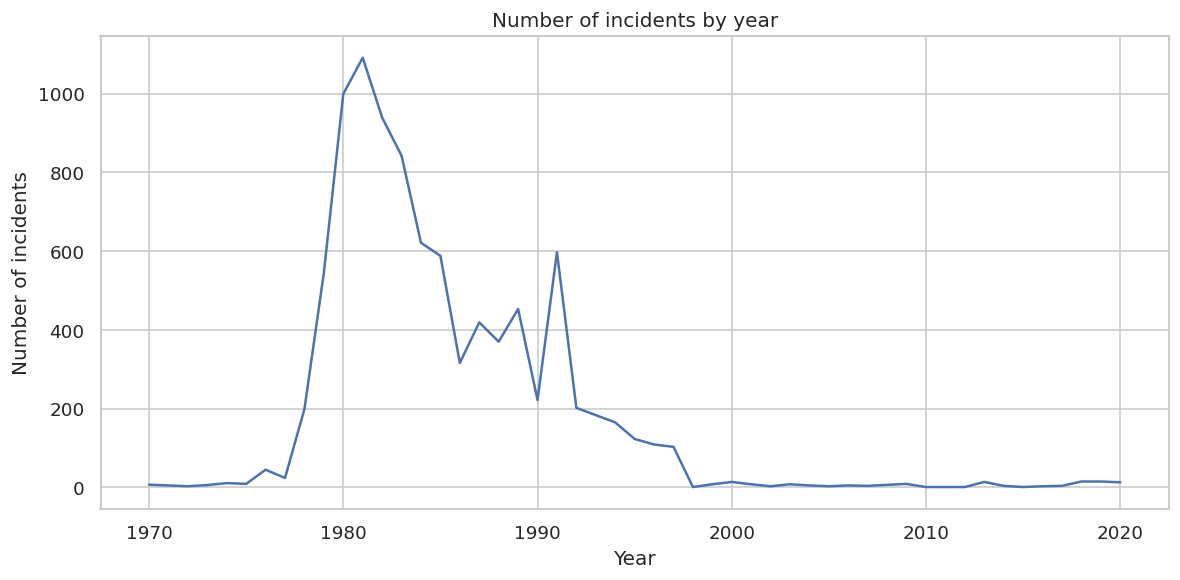

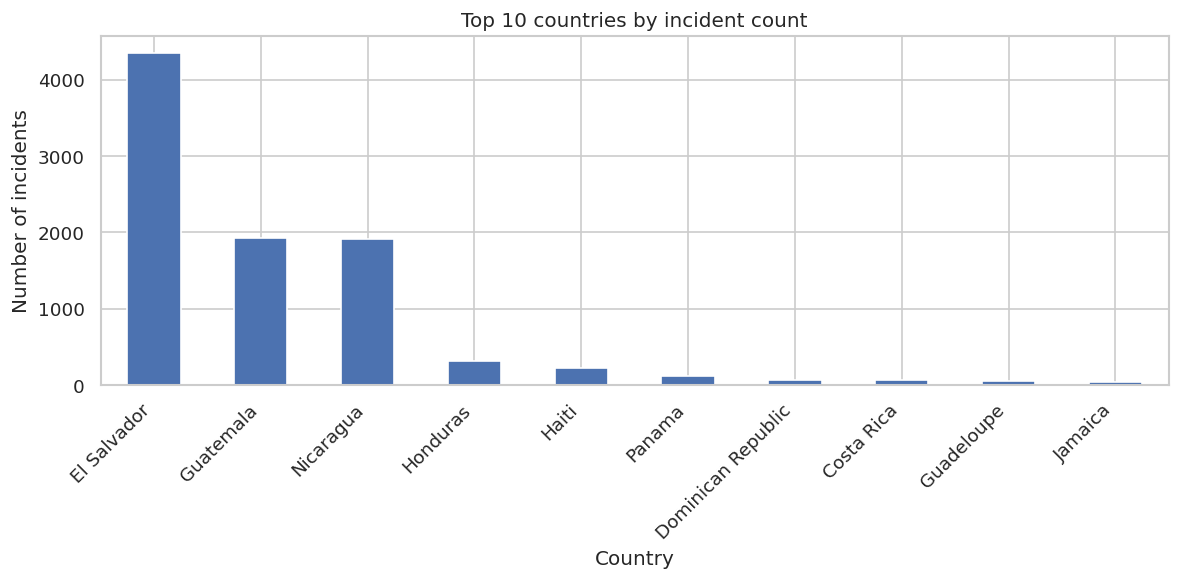

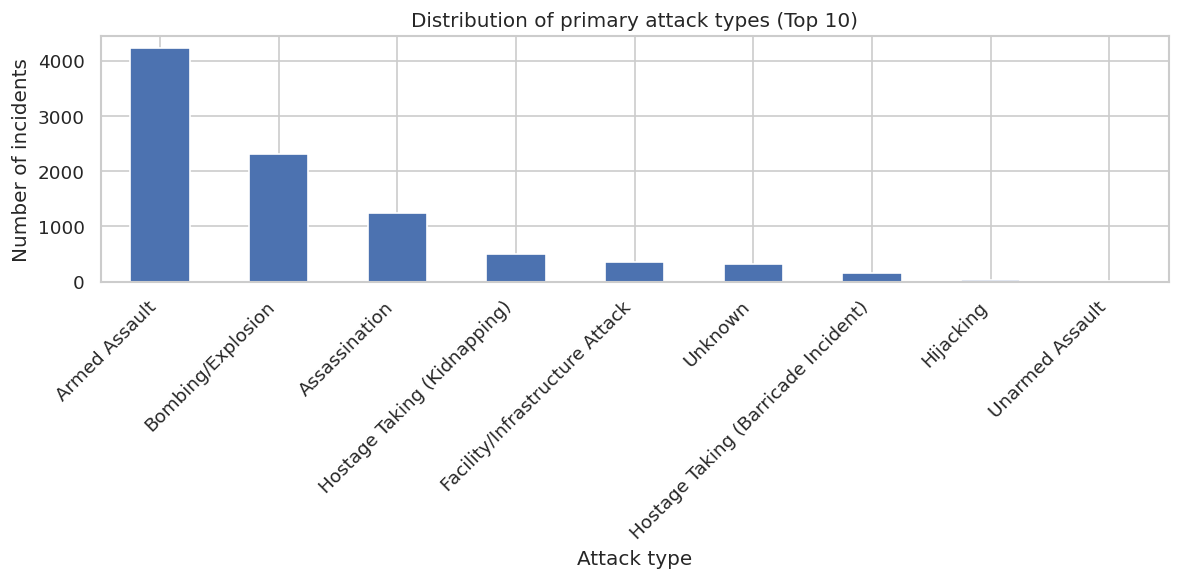

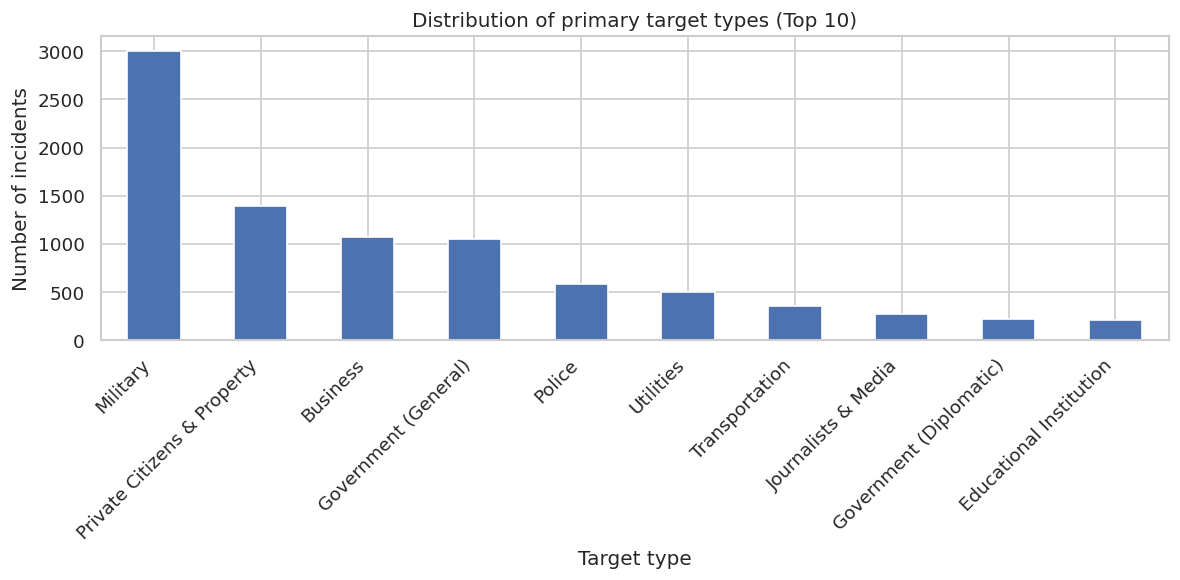

In [29]:

if "iyear" in df.columns:
    plt.figure(figsize=(10, 5))
    df["iyear"].value_counts().sort_index().plot(kind="line")
    plt.title("Number of incidents by year")
    plt.xlabel("Year")
    plt.ylabel("Number of incidents")
    plt.tight_layout()
    plt.show()


if "country_txt" in df.columns:
    plt.figure(figsize=(10, 5))
    df["country_txt"].value_counts().head(10).plot(kind="bar")
    plt.title("Top 10 countries by incident count")
    plt.xlabel("Country")
    plt.ylabel("Number of incidents")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


if "attacktype1_txt" in df.columns:
    plt.figure(figsize=(10, 5))
    df["attacktype1_txt"].value_counts().head(10).plot(kind="bar")
    plt.title("Distribution of primary attack types (Top 10)")
    plt.xlabel("Attack type")
    plt.ylabel("Number of incidents")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

if "targtype1_txt" in df.columns:
    plt.figure(figsize=(10, 5))
    df["targtype1_txt"].value_counts().head(10).plot(kind="bar")
    plt.title("Distribution of primary target types (Top 10)")
    plt.xlabel("Target type")
    plt.ylabel("Number of incidents")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


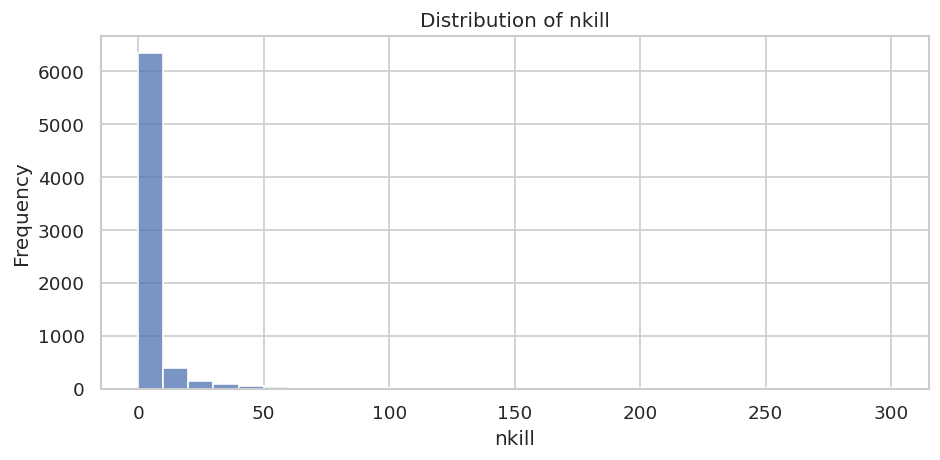

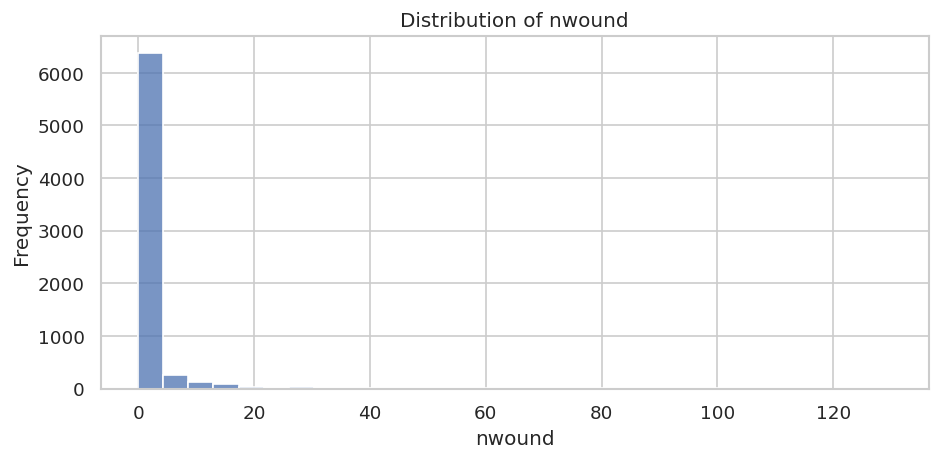

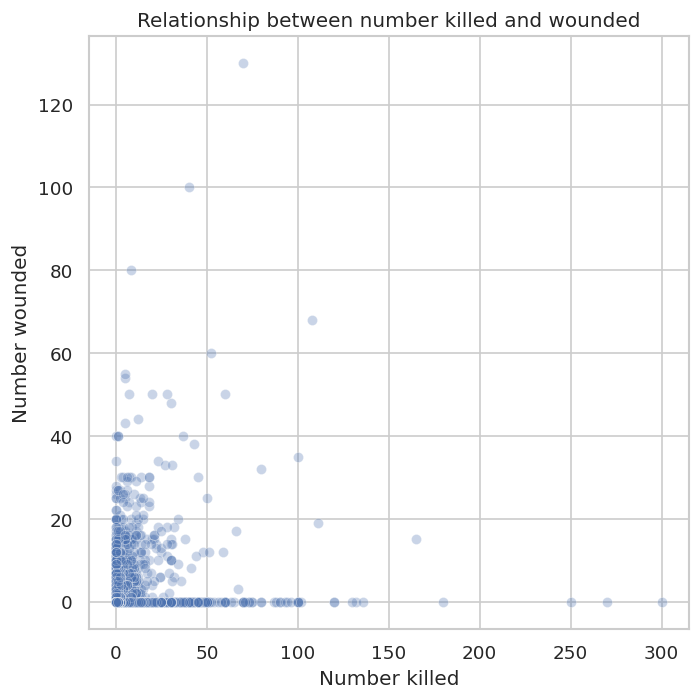

In [30]:

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col].dropna(), bins=30, kde=False)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

if set(["nkill", "nwound"]).issubset(df.columns):
    plt.figure(figsize=(6, 6))
    sns.scatterplot(data=df, x="nkill", y="nwound", alpha=0.3)
    plt.title("Relationship between number killed and wounded")
    plt.xlabel("Number killed")
    plt.ylabel("Number wounded")
    plt.tight_layout()
    plt.show()


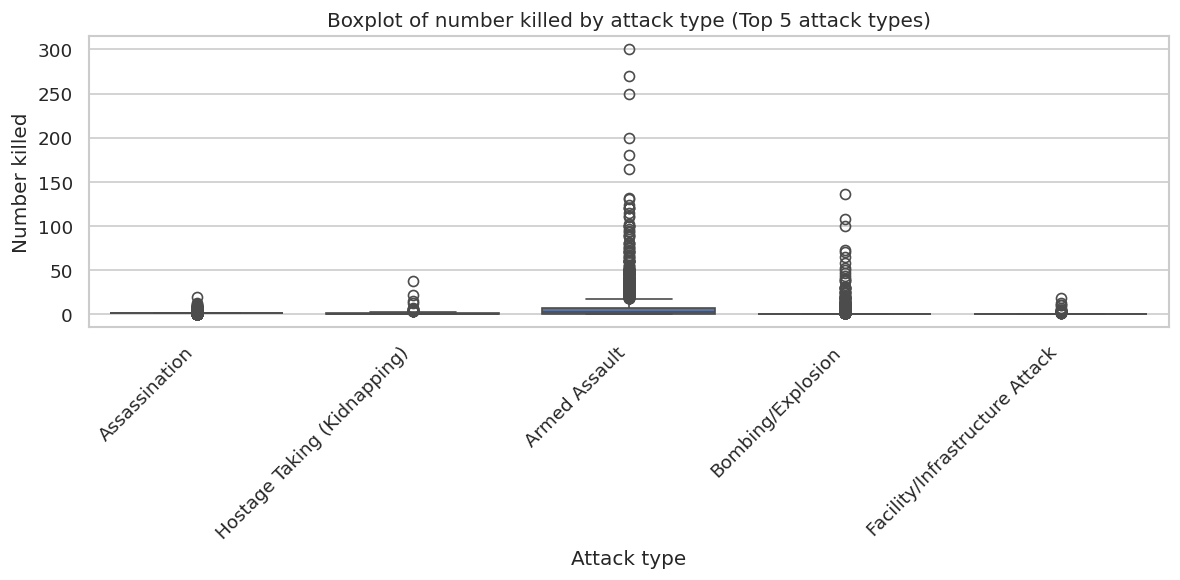

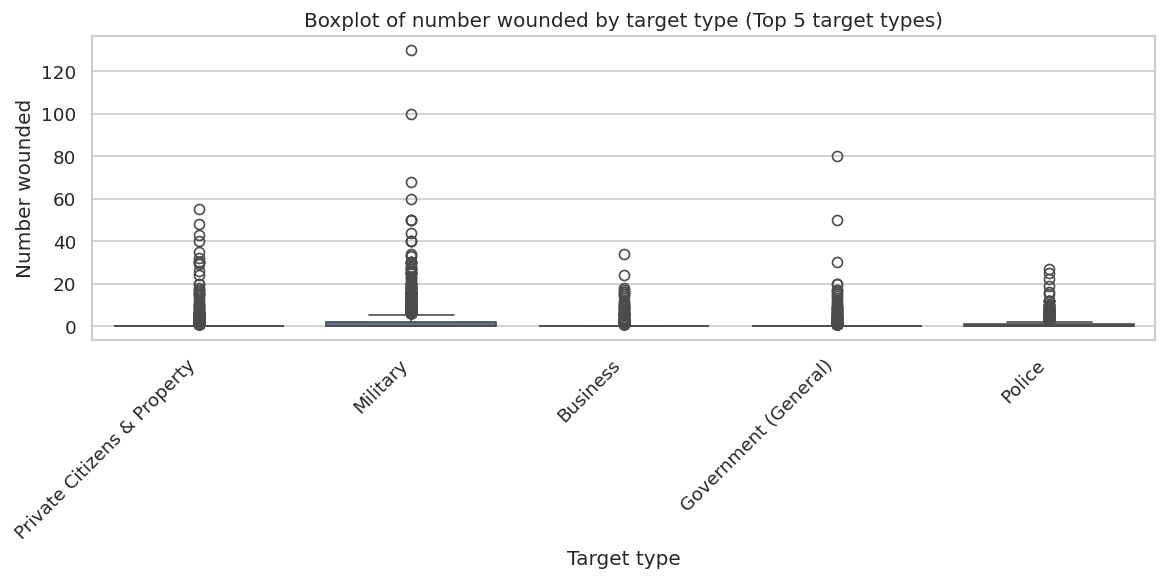

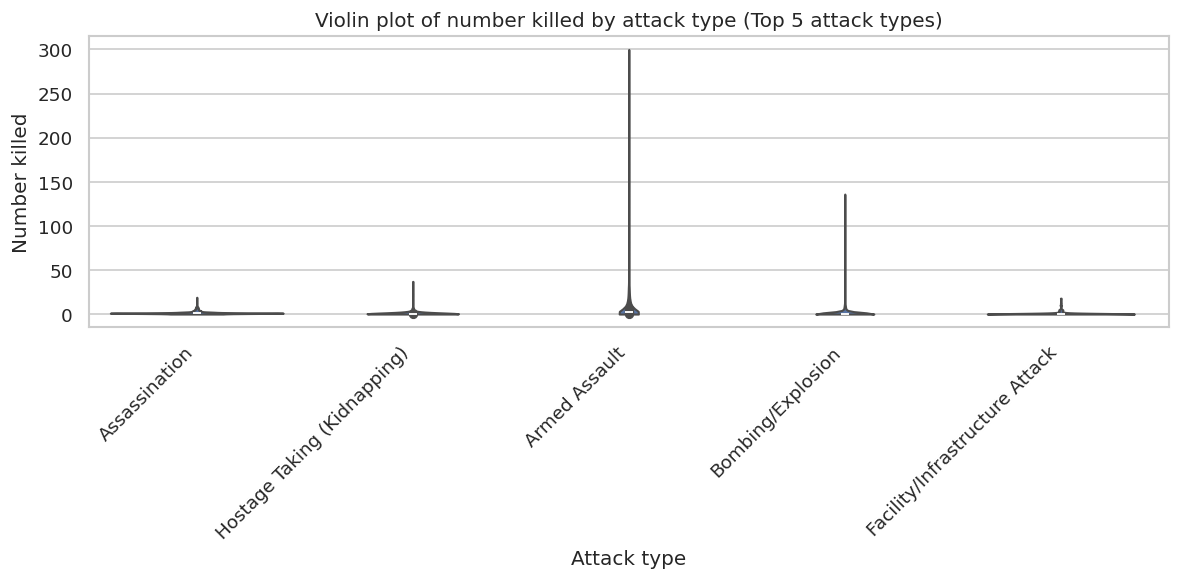

In [31]:

def top_n_categories(series, n=5):
    return series.value_counts().head(n).index


if set(["attacktype1_txt", "nkill"]).issubset(df.columns):
    top_attacks = top_n_categories(df["attacktype1_txt"], n=5)
    subset = df[df["attacktype1_txt"].isin(top_attacks) & df["nkill"].notna()]

    plt.figure(figsize=(10, 5))
    sns.boxplot(data=subset, x="attacktype1_txt", y="nkill")
    plt.title("Boxplot of number killed by attack type (Top 5 attack types)")
    plt.xlabel("Attack type")
    plt.ylabel("Number killed")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


if set(["targtype1_txt", "nwound"]).issubset(df.columns):
    top_targets = top_n_categories(df["targtype1_txt"], n=5)
    subset = df[df["targtype1_txt"].isin(top_targets) & df["nwound"].notna()]

    plt.figure(figsize=(10, 5))
    sns.boxplot(data=subset, x="targtype1_txt", y="nwound")
    plt.title("Boxplot of number wounded by target type (Top 5 target types)")
    plt.xlabel("Target type")
    plt.ylabel("Number wounded")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


if set(["attacktype1_txt", "nkill"]).issubset(df.columns):
    top_attacks = top_n_categories(df["attacktype1_txt"], n=5)
    subset = df[df["attacktype1_txt"].isin(top_attacks) & df["nkill"].notna()]

    plt.figure(figsize=(10, 5))
    sns.violinplot(data=subset, x="attacktype1_txt", y="nkill", cut=0)
    plt.title("Violin plot of number killed by attack type (Top 5 attack types)")
    plt.xlabel("Attack type")
    plt.ylabel("Number killed")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


Subset for Excel

In [32]:

subset_cols = [
    c for c in [
        "iyear",
        "country_txt",
        "attacktype1_txt",
        "targtype1_txt",
        "nkill",
        "nwound"
    ]
    if c in df.columns
]

eda_subset = df[subset_cols].copy()
subset_path = "/content/region_2_eda_subset.csv"
eda_subset.to_csv(subset_path, index=False)

print(f"\nEDA subset saved to: {subset_path}")
print("Download this CSV from Colab and open it in Excel to create additional visualizations.")



EDA subset saved to: /content/region_2_eda_subset.csv
Download this CSV from Colab and open it in Excel to create additional visualizations.
